# RadIAnce: Parametric Roof Irradiance Emulation Framework

In this notebook, you will develop an emulator for the annual irradiance and surface area of a parametric roof. The roof geometry is characterized by eight predefined geometric parameters. A computational model has been used to evaluate the yearly irradiance on a mesh discretization of the reconstructed roof; the outputs may therefore be affected by numerical errors.
The goal is to enable efficient solar potential assessment for energy systems analysis and design optimization.

Using Monte Carlo sampling, a dataset has been constructed consisting of 20000 parameter instances and their corresponding two-dimensional outputs. The data are provided in the file `SCTdata20K.csv`.

Note that the ranges of the eight parameters are defined in the following array:

In [12]:
import numpy as np
ranges = np.array([
    [0,5],  #p1
    [0,10], #p2
    [0,5],  #p3
    [0,4],  #p4
    [0,4],  #p5
    [0,4],  #p6
    [3,13], #p7
    [1,7],  #p8
])

## Load data

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('SCTdata20K.csv', delimiter=';', skip_header = 0)
print(data.shape)

(20000, 10)


In [14]:
num_params = 8
num_output = 2
num_samples = 20000

# num_samples = data.shape[0]

params = data[:num_samples,:num_params]
output = data[:num_samples,num_params:]

output[:,1] = output[:,1] * 1e3 # convert to MWh/year

label_params = [f'p{p+1}' for p in range(num_params)]
label_output = ['area [m^2]', 'radiation [MWh/year]']

## Data visualization

Histograms showing the distribution of the two outputs (area and radiation)

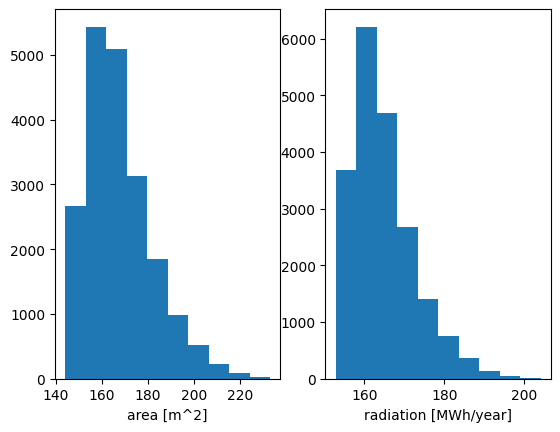

In [15]:
fig, axs = plt.subplots(1,num_output)
for o in range(num_output):
    axs[o].hist(output[:,o])
    axs[o].set_xlabel(label_output[o])

Scatterplot to show the correlation between the two outputs (area and radiation)

Text(0, 0.5, 'radiation [MWh/year]')

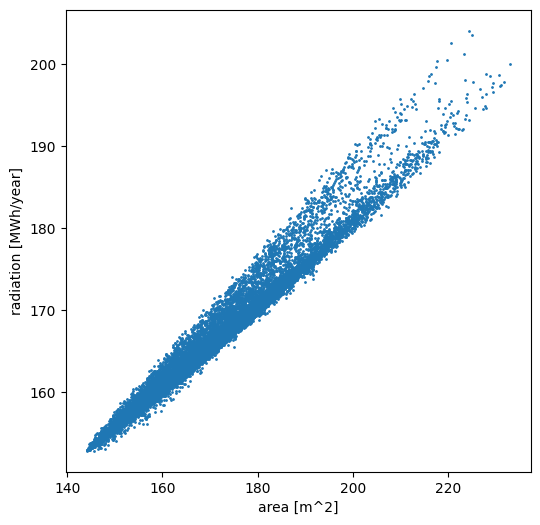

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(output[:,0], output[:,1], s = 1)
ax.set_xlabel(label_output[0])
ax.set_ylabel(label_output[1])

# Signature of the function

You are required to implement the function `checkpoint_implementation(params)`, which implement the surrogate model. 

The input argument params is a NumPy array of shape (num_samples, 8), where each row represents a roof configuration defined by the eight geometric parameters. The function must work for an arbitrary number of samples.

The function should return a NumPy array predicted_output with shape (num_samples, 2), matching the structure of the reference outputs provided in the dataset. The second column must contain the predicted annual irradiance, and the first column must contain the predicted roof surface area. 

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# === LOAD DATA ===
data = np.genfromtxt('SCTdata20K.csv', delimiter=';')

X = data[:, :8]
y = data[:, 8:]
y[:,1] *= 1e3  # convert irradiance

# === TRAIN / VALIDATION SPLIT ===
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === MODEL (più veloce) ===
model = RandomForestRegressor(
    n_estimators=150,      # ridotto (veloce ma stabile)
    max_depth=20,          # limita profondità
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# === VALIDATION ERROR ===
y_val_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 3.4300792216740565


In [3]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_area = np.sqrt(mean_squared_error(y_val[:,0], y_val_pred[:,0]))
rmse_rad  = np.sqrt(mean_squared_error(y_val[:,1], y_val_pred[:,1]))

print("RMSE area [m^2]:", rmse_area)
print("RMSE radiation [MWh/year]:", rmse_rad)

RMSE area [m^2]: 4.201902847603041
RMSE radiation [MWh/year]: 2.423819175026404


In [4]:
mape_area = np.mean(np.abs((y_val_pred[:,0]-y_val[:,0]) / y_val[:,0])) * 100
mape_rad  = np.mean(np.abs((y_val_pred[:,1]-y_val[:,1]) / y_val[:,1])) * 100

print("MAPE area [%]:", mape_area)
print("MAPE radiation [%]:", mape_rad)

MAPE area [%]: 1.8790318024622488
MAPE radiation [%]: 1.0874437460700763


In [5]:
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [6]:
def checkpoint_implementation(params):
    return model.predict(params)